In [11]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import timm
import wandb
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm
from lime import lime_image
from skimage.segmentation import mark_boundaries

device = torch.device('cuda')
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"Free : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1024**3:.1f}GB")

with open('../data/data_config.pkl', 'rb') as f:
    config = pickle.load(f)

CLASSES    = config['classes']
IMAGE_SIZE = config['image_size']
test_df    = config['test_df']
SEG_DIR    = '../data/segmented_images'

os.makedirs('../results/lime', exist_ok=True)

print(f"Classes : {len(CLASSES)}")
print(f"Test    : {len(test_df):,}")
print("✅ Setup done!")

GPU  : Tesla V100-PCIE-32GB
Free : 30.5GB
Classes : 15
Test    : 22,424
✅ Setup done!


In [12]:
pip install lime scikit-image

Note: you may need to restart the kernel to use updated packages.


In [13]:
wandb.init(
    project='xray-classification',
    name='04d-lime_last',
    config={
        'method': 'LIME',
        'models': ['ResNet50', 'DenseNet121', 'EfficientNet', 'VGG16', 'ConvNeXt', 'ViT'],
        'bbox_images': 880,
        'iou_threshold': 0.5,
        'num_samples': 500
    }
)
print("✅ Wandb initialized!")

✅ Wandb initialized!


In [14]:
models = {}

resnet = timm.create_model('resnet50', pretrained=False, num_classes=len(CLASSES))
resnet.load_state_dict(torch.load('../checkpoints/ResNet50/best.pt', map_location=device, weights_only=False)['model_state'])
models['ResNet50'] = resnet.to(device).eval()
print("✅ ResNet50 loaded!")

densenet = timm.create_model('densenet121', pretrained=False, num_classes=len(CLASSES))
densenet.load_state_dict(torch.load('../checkpoints/DenseNet121/best.pt', map_location=device, weights_only=False)['model_state'])
models['DenseNet121'] = densenet.to(device).eval()
print("✅ DenseNet121 loaded!")

efficientnet = timm.create_model('efficientnet_b0', pretrained=False, num_classes=len(CLASSES))
efficientnet.load_state_dict(torch.load('../checkpoints/EfficientNet-B0/best.pt', map_location=device, weights_only=False)['model_state'])
models['EfficientNet'] = efficientnet.to(device).eval()
print("✅ EfficientNet loaded!")

vgg = timm.create_model('vgg16', pretrained=False, num_classes=len(CLASSES))
vgg.load_state_dict(torch.load('../checkpoints/VGG-16/best.pt', map_location=device, weights_only=False)['model_state'])
models['VGG16'] = vgg.to(device).eval()
print("✅ VGG16 loaded!")

convnext = timm.create_model('convnext_base', pretrained=False, num_classes=len(CLASSES))
convnext.load_state_dict(torch.load('../checkpoints/ConvNeXt/best.pt', map_location=device, weights_only=False)['model_state'])
models['ConvNeXt'] = convnext.to(device).eval()
print("✅ ConvNeXt loaded!")

vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=len(CLASSES))
vit.load_state_dict(torch.load('../checkpoints/ViT/best.pt', map_location=device, weights_only=False)['model_state'])
models['ViT'] = vit.to(device).eval()
print("✅ ViT loaded!")

print(f"\n✅ All {len(models)} models loaded! (LIME is model-agnostic — ViT included)")

✅ ResNet50 loaded!
✅ DenseNet121 loaded!
✅ EfficientNet loaded!
✅ VGG16 loaded!
✅ ConvNeXt loaded!
✅ ViT loaded!

✅ All 6 models loaded! (LIME is model-agnostic — ViT included)


In [15]:
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def make_predict_fn(model):
    def predict_fn(images_np):
        # images_np: (batch, H, W, 3) uint8, values 0-255
        batch = torch.stack([val_transform(Image.fromarray(img.astype(np.uint8))) for img in images_np])
        batch = batch.to(device)
        with torch.no_grad():
            logits = model(batch)
            probs = torch.sigmoid(logits)   # multi-label — sigmoid, not softmax
        return probs.cpu().numpy()
    return predict_fn
The computation is actually running fine in the background — the browser just can't handle displaying all the progress bars!
predict_fns = {name: make_predict_fn(m) for name, m in models.items()}
print("✅ Predict functions created for all models!")

✅ Predict functions created for all models!


In [16]:
bbox_df = pd.read_csv('../data/NIH/BBox_List_2017_Official_NIH.csv')
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})
bbox_df = bbox_df[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]

label_map = {'Infiltrate': 'Infiltration'}
bbox_df['Finding Label'] = bbox_df['Finding Label'].replace(label_map)
bbox_df = bbox_df[bbox_df['Finding Label'].isin(CLASSES)].reset_index(drop=True)

ORIGINAL_RES = 1024
scale = IMAGE_SIZE / ORIGINAL_RES
bbox_df['x_scaled'] = bbox_df['x'] * scale
bbox_df['y_scaled'] = bbox_df['y'] * scale
bbox_df['w_scaled'] = bbox_df['w'] * scale
bbox_df['h_scaled'] = bbox_df['h'] * scale

print(f"✅ {len(bbox_df)} bbox annotations ready, scale={scale:.4f}")

✅ 984 bbox annotations ready, scale=0.2188


In [17]:
def lime_mask_to_bbox_mask(explanation, label_idx, positive_only=True, num_features=5):
    """Get binary mask of the top LIME superpixels for the target class"""
    _, mask = explanation.get_image_and_mask(
        label_idx, positive_only=positive_only, num_features=num_features, hide_rest=False
    )
    return (mask > 0).astype(np.uint8)

def gt_bbox_to_mask(x, y, w, h, img_size):
    mask = np.zeros((img_size, img_size), dtype=np.uint8)
    x1, y1 = max(0, int(round(x))), max(0, int(round(y)))
    x2, y2 = min(img_size, int(round(x + w))), min(img_size, int(round(y + h)))
    mask[y1:y2, x1:x2] = 1
    return mask

def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

print("✅ Helper functions defined!")

✅ Helper functions defined!


In [18]:
import gc
import torch
import json
import os

explainer = lime_image.LimeImageExplainer()
iou_results = {model_name: [] for model_name in models}
detailed_records = []

# --- Resume support: load previous progress if it exists ---
CHECKPOINT_FILE = "lime_iou_checkpoint.json"
processed_keys = set()

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "r") as f:
        detailed_records = json.load(f)
    for r in detailed_records:
        processed_keys.add((r['Image Index'], r['Model']))
    for r in detailed_records:
        iou_results[r['Model']].append(r['IoU'])
    print(f"Resuming: {len(detailed_records)} records already done.")

for idx, row in bbox_df.iterrows():
    if idx % 50 == 0:
        print(f"Progress: {idx}/{len(bbox_df)} images done", flush=True)
    fname = row['Image Index']
    gt_label = row['Finding Label']
    if gt_label not in CLASSES:
        continue
    gt_class_idx = CLASSES.index(gt_label)
    img_path = os.path.join(SEG_DIR, fname)
    img = Image.open(img_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    img_np = np.array(img)
    gt_mask = gt_bbox_to_mask(row['x_scaled'], row['y_scaled'], row['w_scaled'], row['h_scaled'], IMAGE_SIZE)

    for model_name, predict_fn in predict_fns.items():
        if (fname, model_name) in processed_keys:
            continue

        explanation = None
        try:
            explanation = explainer.explain_instance(
                img_np,
                predict_fn,
                labels=(gt_class_idx,),
                top_labels=None,     # <-- THE ACTUAL FIX: forces LIME to use `labels`, not its own top-5
                hide_color=0,
                num_samples=100,
                batch_size=32,
                progress_bar=False
            )
            lime_mask = lime_mask_to_bbox_mask(explanation, gt_class_idx, positive_only=True, num_features=5)
            iou = compute_iou(lime_mask, gt_mask)

        except torch.cuda.OutOfMemoryError:
            print(f"⚠️ OOM on {fname} / {model_name}, clearing cache and skipping.")
            torch.cuda.empty_cache()
            gc.collect()
            iou = None

        except KeyError:
            print(f"⚠️ Label {gt_class_idx} not in LIME explanation for {fname} / {model_name}, skipping.")
            iou = None

        except Exception as e:
            print(f"⚠️ Unexpected error on {fname} / {model_name}: {e}")
            iou = None

        iou_results[model_name].append(iou)
        record = {'Image Index': fname, 'Finding Label': gt_label, 'Model': model_name, 'IoU': iou}
        detailed_records.append(record)

        if explanation is not None:
            del explanation
        torch.cuda.empty_cache()
        gc.collect()

    if idx % 20 == 0:
        with open(CHECKPOINT_FILE, "w") as f:
            json.dump(detailed_records, f)

with open(CHECKPOINT_FILE, "w") as f:
    json.dump(detailed_records, f)

print("\n✅ LIME + IoU computed!")

Resuming: 5436 records already done.
Progress: 0/984 images done
Progress: 50/984 images done
Progress: 100/984 images done
Progress: 150/984 images done
Progress: 200/984 images done
Progress: 250/984 images done
Progress: 300/984 images done
Progress: 350/984 images done
Progress: 400/984 images done
Progress: 450/984 images done
Progress: 500/984 images done
Progress: 550/984 images done
Progress: 600/984 images done
Progress: 650/984 images done
Progress: 700/984 images done
Progress: 750/984 images done
Progress: 800/984 images done
Progress: 850/984 images done
Progress: 900/984 images done
Progress: 950/984 images done

✅ LIME + IoU computed!


Total records : 5436
Valid IoU     : 5436

  LIME IoU SCORES — ALL MODELS
  ResNet50        → Mean IoU: 0.0747
  DenseNet121     → Mean IoU: 0.0938
  EfficientNet    → Mean IoU: 0.0782
  VGG16           → Mean IoU: 0.1017
  ConvNeXt        → Mean IoU: 0.0889
  ViT             → Mean IoU: 0.1013
🏆 Best Model: VGG16 (0.1017)


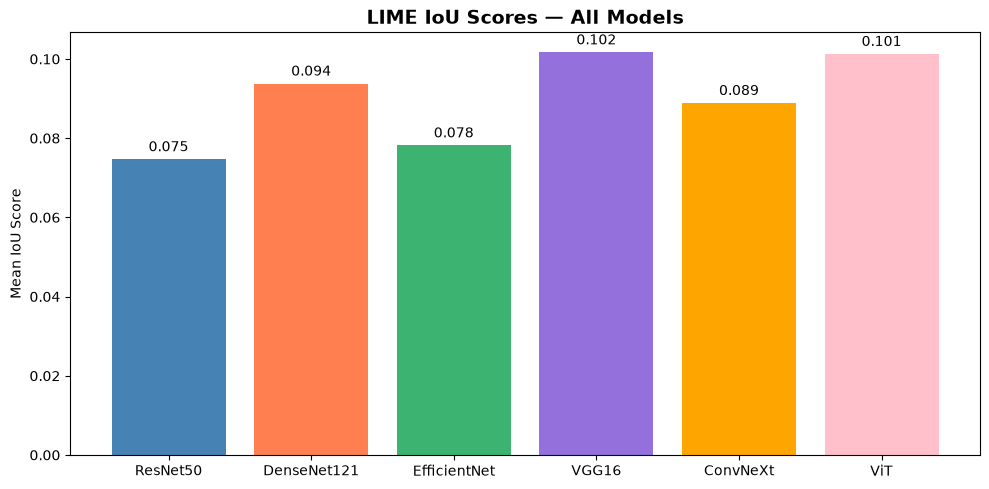

lime_iou_ConvNeXt,▁
lime_iou_DenseNet121,▁
lime_iou_EfficientNet,▁
lime_iou_ResNet50,▁
lime_iou_VGG16,▁
lime_iou_ViT,▁
lime_iou_ConvNeXt,0.0889
lime_iou_DenseNet121,0.0938
lime_iou_EfficientNet,0.0782
lime_iou_ResNet50,0.0747
lime_iou_VGG16,0.1017



✅ LIME notebook complete!
👉 Now open 04a_gradcam.ipynb!


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Load all saved results
with open('lime_iou_checkpoint.json', 'r') as f:
    detailed_records = json.load(f)

results_df = pd.DataFrame(detailed_records)
results_df = results_df.dropna(subset=['IoU'])

print(f"Total records : {len(detailed_records)}")
print(f"Valid IoU     : {len(results_df)}")

# Summary
print("\n" + "="*50)
print("  LIME IoU SCORES — ALL MODELS")
print("="*50)

summary = {}
for model_name in models.keys():
    model_df = results_df[results_df['Model'] == model_name]
    mean_iou = model_df['IoU'].mean()
    summary[model_name] = round(mean_iou, 4)
    print(f"  {model_name:15s} → Mean IoU: {mean_iou:.4f}")

best_model = max(summary, key=summary.get)
print("="*50)
print(f"🏆 Best Model: {best_model} ({summary[best_model]:.4f})")

# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(summary.keys(), summary.values(),
               color=['steelblue','coral','mediumseagreen',
                      'mediumpurple','orange','pink'])
plt.title('LIME IoU Scores — All Models', fontsize=14, fontweight='bold')
plt.ylabel('Mean IoU Score')
for bar, val in zip(bars, summary.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../results/lime/lime_iou_comparison.png', dpi=150)
plt.show()

# Log to wandb
wandb.log({'lime_iou_comparison': wandb.Image('../results/lime/lime_iou_comparison.png')})
for name, iou in summary.items():
    wandb.log({f'lime_iou_{name}': iou})

wandb.finish()
print("\n✅ LIME notebook complete!")
print("👉 Now open 04a_gradcam.ipynb!")